# Intro to Linear Regression

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
RANDOM_STATE = 42

# Configure NumPy.
rng = np.random.default_rng(seed=RANDOM_STATE)
np.set_printoptions(linewidth=100)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 Fundamentals

### 1.1 Notations

#### Dataset

$$
\large
D\,:=\,\biggl\{\bigl(X^{(i)},\,y^{(i)}\bigr)\;;\;X^{(i)}\in\mathbb{R}^d\;;\;y^{(i)}\in\mathbb{R}^1\biggr\}_{i=1}^n
$$

#### Feature Vector

$$
\large
\begin{aligned}
& X       && \text{Features matrix (Dataset)} \\[5pt]
& X^{(i)} && i^{\text{th}}\;\text{data-point (row in the dataset)} \\[5pt]
& X_i     && i^{\text{th}}\;\text{feature vector in matrix (column in the dataset)} \\[5pt]
& x_i     && i^{\text{th}}\;\text{value in feature vector}
\end{aligned}
$$

#### Class Label

##### True Target

Single $i^{\text{th}}$ true Target value:

$$
\large
y^{(i)}\quad\text{or}\quad{y}_{\text{true}}^{(i)}
$$

##### Predicted Target

Single $i^{\text{th}}$ predicted Target value:

$$
\large
\hat{y}^{(i)}\quad\text{or}\quad{y}_{\text{pred}}^{(i)}
$$

#### Goal

Goal of machine Learning is to get a Predicted value very close to actual/true Target value.

$$
\large
\hat{y}^{(i)}\;\simeq\;y^{(i)}
$$

#### Hypothesis / Mapping function

We get predicted value from an Hypothesis or a mapping function.

$$
\large
\hat{y}\;=\;f(x)
$$

Where,

- $\hat{y}$ - Predicted target value
- $f(x)$ - Hypothesis

### 1.2 Mathematical Intuition

#### What is Regression?

- Regression is defined as explaining the variance in $y$ using the variance observed in $x$.
- Regression is explicitly observed and modelled using a **Linear Relationship**.

#### Linear Relationship

Linear equation can be used to represent the Linear Relationship between $x$ and $y$.

##### One Dimension

Linear equation to represent linear relationship between single input variable $x$, of $1$ dimension, and target variable $y$:

$$
\large
\hat{y} = w_1\,x_1\;+\;w_0
$$

##### Multiple Dimensions

Linear equation to represent linear relationship between feature vector $x$, of $d$ dimension, and target variable $y$:

$$
\large
\hat{y} = w_1\,x_1\;+\;w_2\,x_2\;+\;\ldots\;+\;w_d\,x_d\;+\;w_0
$$

#### Regression Model/Line

Predicting target variable $y$ using a regression line resulting from the linear relationship.

#### Properties

- These Lines (Linear equations) acts as **Decision Boundary** for Classification problem.
- These Lines (Linear equations) acts as **Regression Line** for Regression problem.

<div style="display: inline-block">

| Features   | Decision Boundary           |
| :--------- | :-------------------------- |
| 1 Feature  | Straight line in 2D space   |
| 2 Features | Plane in 3D space           |
| d Features | Hyperplane in $d + 1$ space |

</div>

### 1.3 Regression Models

#### Types of Regression Models

1. Linear Regression
2. Logistic Regression
3. Polynomial Regression
4. Step-wise Regression
5. Ridge Regression
6. Lasso Regression
7. Elastic Net Regression

## 2 Linear Regression

### 2.1 Introduction

Lets understand Linear Regression using single variable.

#### Goal of LR

Goal of Linear Regression is to fit a model (line, curve, etc.) on Features $X$ to predict Target $y$.

#### Weights and Intercept

In order to build a straight line we need two components $x$ and $w$.

$$
\large
\hat{y} = w_1\,x_1\;+\;w_2\,x_2\;+\;\ldots\;+\;w_d\,x_d\;+\;w_0
$$

In the above equation,

- $x$ represents one single row from the dataset (a.k.a feature vector) which is already known.
- $w$ represents the corresponding coefficients (a.k.a weight vector) which is unknown.
- Linear Regression Algorithm helps us in learning these weights from the dataset.

#### API

In [3]:
from sklearn.linear_model import LinearRegression

### 2.2 Examples

#### Example #1: Linear Regression

##### Data-points

In [4]:
X = [37, 182, 296, 353, 414, 520, 648, 779, 861, 905]
y = [0.83, 1.07, 2.98, 3.55, 4.79, 5.62, 6.14, 7.46, 8.31, 9.27]

##### Plot Regression Line

In [5]:
dp_style = {"color": "blue", "alpha": 1}  # Blue data points
reg_style = {"color": "red", "alpha": 0.5, "label": "Regression Line"}  # Red regression line

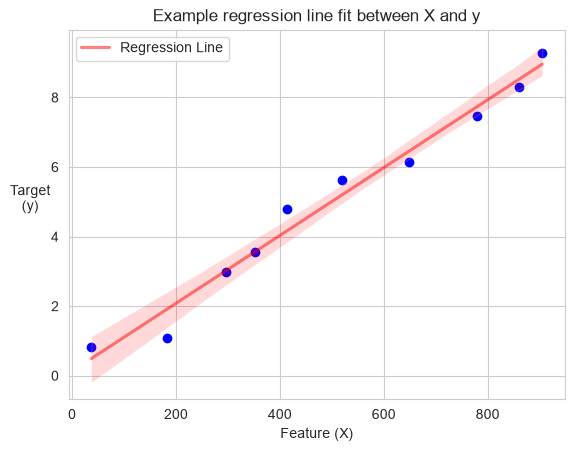

In [6]:
sns.regplot(x=X, y=y, scatter_kws=dp_style, line_kws=reg_style)
plt.title("Example regression line fit between X and y")
plt.xlabel("Feature (X)")
plt.ylabel("Target\n(y)", rotation=0, labelpad=15)
plt.legend()

plt.show()

#### Example #2: Polynomial Regression

##### Data-points

In [7]:
X = [-2.0, -1.56, -1.11, -0.67, -0.22, 0.22, 0.67, 1.11, 1.56, 2.0]
y = [1.73, 0.37, 1.51, 0.27, 2.69, 2.37, 3.91, 4.46, 7.08, 7.79]

##### Plot Regression Curve

In [8]:
dp_style = {"color": "blue", "alpha": 0.8}  # Blue data points
reg_style = {"color": "red", "alpha": 0.5, "label": "Regression Curve"}  # Red regression line

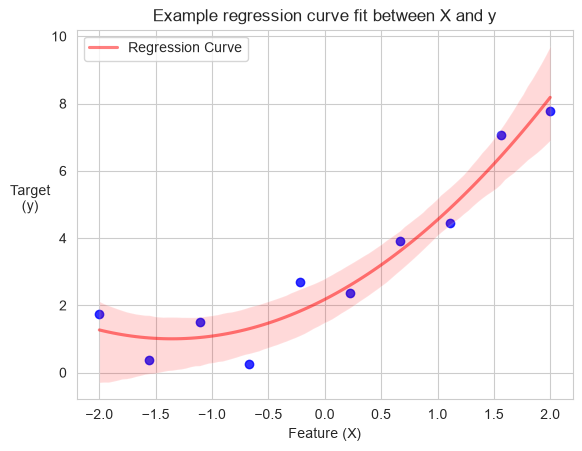

In [9]:
sns.regplot(x=X, y=y, order=2, scatter_kws=dp_style, line_kws=reg_style)
plt.title("Example regression curve fit between X and y")
plt.xlabel("Feature (X)")
plt.ylabel("Target\n(y)", rotation=0, labelpad=15)
plt.legend()

plt.show()

### 2.3 Fit Regression Line

#### 1 Dataset

In [10]:
X = [37, 182, 296, 353, 414, 520, 648, 779, 861, 905]
y = [0.83, 1.07, 2.98, 3.55, 4.79, 5.62, 6.14, 7.46, 8.31, 9.27]

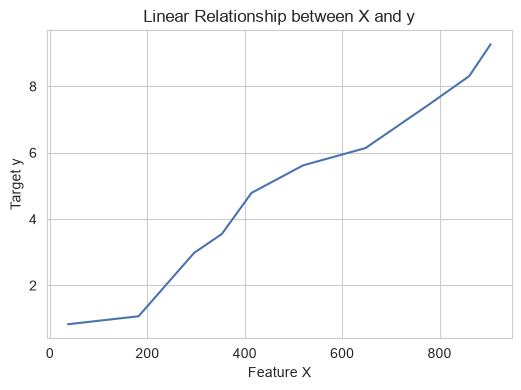

In [11]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=X, y=y)
plt.title("Linear Relationship between X and y")
plt.xlabel("Feature X")
plt.ylabel("Target y")

plt.show()

#### 2 Training Setup

In [12]:
X = np.asarray(X).reshape(-1, 1)
y = np.asarray(y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [14]:
X_train

array([[ 37],
       [779],
       [296],
       [905],
       [414],
       [353],
       [648]])

In [15]:
y_train

array([0.83, 7.46, 2.98, 9.27, 4.79, 3.55, 6.14])

In [16]:
X_test

array([[861],
       [182],
       [520]])

In [17]:
y_test

array([8.31, 1.07, 5.62])

#### 3 Model Initialization

In [18]:
lr_model = LinearRegression()
lr_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 4 Model Training

In [19]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3884
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[740.34]


#### 5 Model Weights

##### Bias

In [20]:
lr_model.intercept_

np.float64(0.38838419306611627)

##### Coefficients or Weights

In [21]:
lr_model.coef_

array([0.0094118])

$$
\large
\begin{aligned}
& \hat{y}\;=\;w_1\,x_1\;+\;w_0 \\[5pt]
& \hat{y}\;=\;0.009412\,x_1\;+\;0.388384
\end{aligned}
$$

#### 6 Target Predictions

In [22]:
y_pred = lr_model.predict(X)
y_pred

array([0.73662093, 2.10133249, 3.17427812, 3.71075094, 4.28487097, 5.28252217, 6.48723306,
       7.72017935, 8.49194727, 8.90606663])

In [23]:
def f(x_i):
    """
    Function to map input `x_i` to target value `y_hat`.
    """
    # Model weights.
    w_1 = lr_model.coef_[0]
    w_0 = lr_model.intercept_

    # Linear equation.
    y_hat = w_1 * x_i + w_0

    # Return predicted value.
    return y_hat.item()

In [24]:
x_1 = 450

In [25]:
y_hat_1 = f(x_1)  # Same as `predict()`.
x_1, y_hat_1

(450, 4.623695903975712)

In [26]:
y_hat_1 = lr_model.predict([[x_1]]).item()
x_1, y_hat_1

(450, 4.623695903975712)

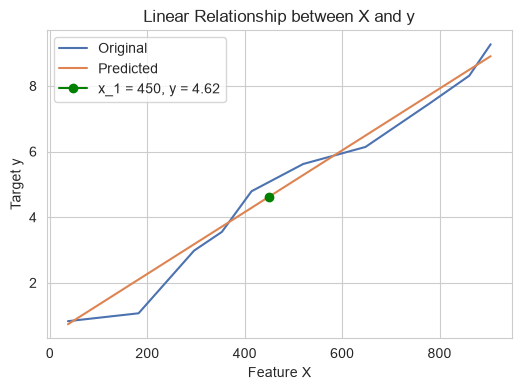

In [27]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=X.flatten(), y=y, label="Original")
sns.lineplot(x=X.flatten(), y=y_pred, label="Predicted")
plt.plot(x_1, f(x_1), color="green", marker="o", label=f"x_1 = {x_1}, y = {y_hat_1:.2f}")
plt.title("Linear Relationship between X and y")
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.legend()

plt.show()

## 3 Model Evaluation

### 3.1 Error

#### What is Error?

Error is the difference between target's actual value (in the dataset) and its prediction from a model.

#### Properties of Errors

- Difference in predictions (a.k.a errors) must be **as small as possible**.
- Ideally, when a model is perfect, the errors must be zero.

#### Example

Errors in predictions of the above dummy dataset can be calculated as:

In [28]:
errors = y - y_pred
errors.round(6)

array([ 0.093379, -1.031332, -0.194278, -0.160751,  0.505129,  0.337478, -0.347233, -0.260179,
       -0.181947,  0.363933])

##### Plot Errors in predictions

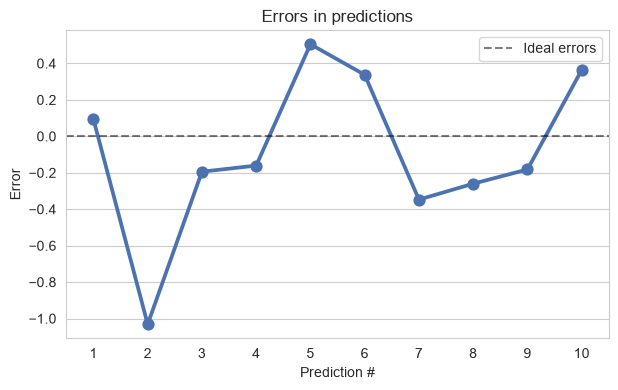

In [29]:
plt.figure(figsize=(7, 4))

sns.pointplot(x=range(1, len(y) + 1), y=errors)
plt.axhline(y=0.0, color="k", linestyle="--", alpha=0.5, label="Ideal errors")
plt.title("Errors in predictions")
plt.xlabel("Prediction #")
plt.ylabel("Error")
plt.legend()

plt.show()

#### Issues with Error

Errors depends on the scale of the features, for example:

1. Errors during house price predictions can be in thousands.
2. Errors during temperature predictions can be in single digits.

Hence there is a need for better evaluation metrics to evaluate model predictions.

### 3.2 Intro to Evaluation Metrics

Evaluation of a model's predictions is done using **Evaluation Metrics**.

#### Need for Evaluation Metrics

1. Simple difference between target's actual and predicted value is not robust enough in evaluating model predictions.
2. Performance of multiple models must be comparable using some metrics inorder to choose the best model.
3. Metrics are needed to measure the performance of a single model.

#### Types of Evaluation Metrics

These are the common Evaluation Metrics used for evaluating Regression models:

1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. Root Mean Squared Error (RMSE)
4. R-squared ($R^2$)
5. Adjusted R-squared (Adj. $R^2$)

#### Properties of Evaluation Metrics

- First three evaluation metrics are errors and their functions can be used as loss function.
- First three evaluation metrics can be used to compare multiple models and choose the best.
- R-squared ($R^2$) can be used to evaluate the performance of single model.
- MSE is chosen as error function for Optimization (using Gradient Descent) over MAE because its **differentiable**.